# SHAP Values - Companion Notebook 3: Using the Python Library

This notebook accompanies Section 6 of `lecture_notes/17_shap_values.pdf`.

Goals:
- train a regression model;
- create a SHAP explainer;
- inspect `values`, `base_values`, and `data`;
- verify the decomposition numerically;
- generate the main SHAP visualizations.

The notebook runs without `shap` installed, but the SHAP-specific cells will print installation guidance instead of plotting. To enable the plots, run:

```python
%pip install shap
```

In [10]:
import importlib.util
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

HAVE_SHAP = importlib.util.find_spec("shap") is not None
if HAVE_SHAP:
    import shap
else:
    print("The 'shap' package is not installed. Run `%pip install shap` to enable SHAP computations and plots.")

## 1. Train a model

We use a regression problem to avoid ambiguity about class dimensions and output scales. The target is the diabetes disease progression score from scikit-learn's built-in dataset.

In [11]:
X, y = load_diabetes(return_X_y=True, as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, pred):.2f}")
print(f"R^2: {r2_score(y_test, pred):.3f}")
X_train.head()

MAE: 42.07
R^2: 0.488


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
16,-0.005515,-0.044642,0.042296,0.049415,0.024574,-0.023861,0.074412,-0.039493,0.052277,0.027917
408,0.063504,-0.044642,-0.050396,0.107944,0.031454,0.019354,-0.017629,0.023608,0.058038,0.040343
432,0.009016,-0.044642,0.055229,-0.005670,0.057597,0.044719,-0.002903,0.023239,0.055686,0.106617
316,0.016281,0.050680,0.014272,0.001215,0.001183,-0.021355,-0.032356,0.034309,0.074966,0.040343
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362


## 2. Choose a background dataset

The notes recommend using a representative sample from the training set. Here we use 100 rows, enough for a stable classroom example without making the notebook too slow.

In [12]:
background = X_train.sample(n=min(100, len(X_train)), random_state=42)
X_explain = X_test.iloc[:80]

background.shape, X_explain.shape

((100, 10), (80, 10))

## 3. Create the explainer and compute SHAP values

`shap.Explainer` auto-selects an appropriate algorithm. For a random forest, it will use a tree-based explainer when possible.

In [13]:
if HAVE_SHAP:
    explainer = shap.Explainer(model, background)
    shap_values = explainer(X_explain)

    print("values shape:", shap_values.values.shape)
    print("base_values shape:", np.shape(shap_values.base_values))
    print("data shape:", np.shape(shap_values.data))
else:
    shap_values = None

values shape: (80, 10)
base_values shape: (80,)
data shape: (80, 10)


## 4. Verify the decomposition

For regression, the decomposition should reconstruct the model prediction:

$$h(x) \approx \phi_0 + \sum_i \phi_i.$$

Small floating-point differences are normal.

In [14]:
if HAVE_SHAP:
    instance_index = 0
    reconstructed = shap_values.base_values[instance_index] + shap_values.values[instance_index].sum()
    model_output = model.predict(X_explain.iloc[[instance_index]])[0]

    print(f"base value phi_0:          {shap_values.base_values[instance_index]:.6f}")
    print(f"sum of SHAP values:        {shap_values.values[instance_index].sum():.6f}")
    print(f"phi_0 + sum(phi_i):        {reconstructed:.6f}")
    print(f"model prediction h(x):     {model_output:.6f}")
    print(f"absolute reconstruction error: {abs(model_output - reconstructed):.12f}")

base value phi_0:          158.860152
sum of SHAP values:        -18.031599
phi_0 + sum(phi_i):        140.828553
model prediction h(x):     140.667799
absolute reconstruction error: 0.160753852202


## 5. Global visualizations

The beeswarm plot shows the distribution of SHAP values feature by feature. The bar plot summarizes global importance with mean absolute SHAP values.

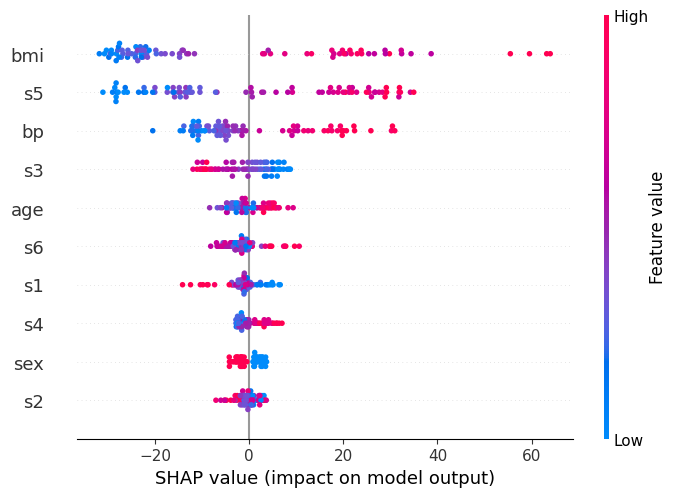

In [15]:
if HAVE_SHAP:
    shap.plots.beeswarm(shap_values, max_display=10)

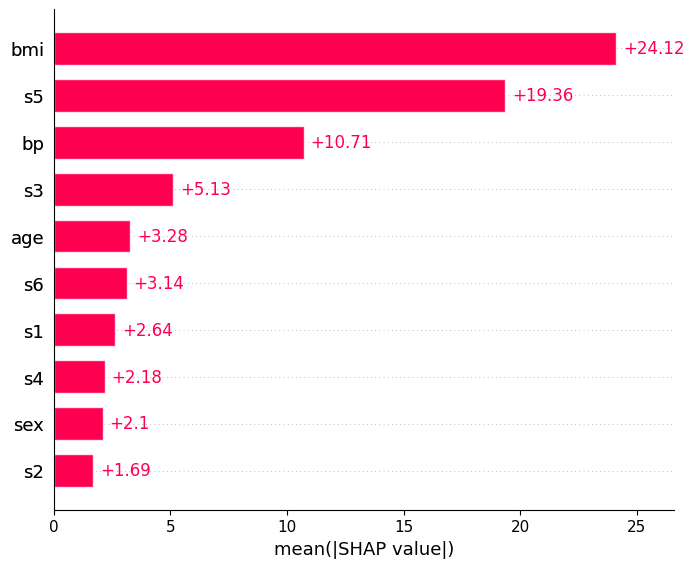

In [16]:
if HAVE_SHAP:
    shap.plots.bar(shap_values, max_display=10)

## 6. Local visualization

The waterfall plot explains one prediction by starting at the baseline and adding feature contributions until it reaches the model output.

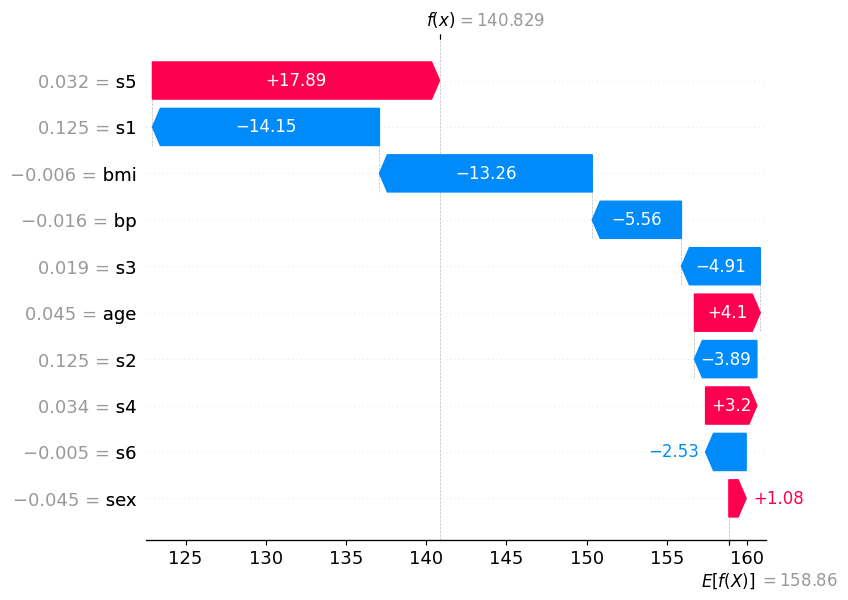

In [17]:
if HAVE_SHAP:
    shap.plots.waterfall(shap_values[0], max_display=10)

## 7. Dependence / scatter plot

A scatter plot helps diagnose how a feature's effect varies with its own value and with potential interacting features.

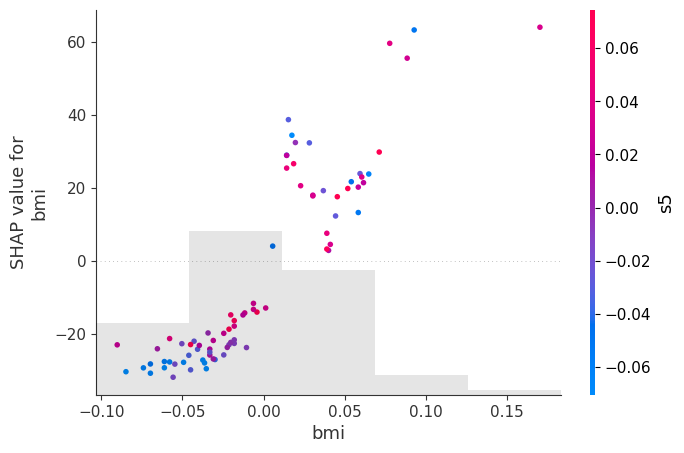

In [18]:
if HAVE_SHAP:
    shap.plots.scatter(shap_values[:, "bmi"], color=shap_values)